# Perform EDA on below insurance dataset

Link: https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health

Perform All steps of EDA and document conclusions and then perform feature engineering.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df = pd.read_csv("data/29_data/insurance_data.csv").drop(columns=["index"])

In [5]:
df.sample(3)

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
118,119,58.0,female,30.1,81,Yes,0,No,southeast,2203.47
387,388,31.0,female,22.1,97,Yes,1,No,southeast,5354.07
1064,1065,28.0,female,20.0,96,Yes,2,Yes,northeast,19798.05


<br>

# **Dataset Summary**

The dataset contains the medical patient information where each row represent a patient.

# **Columns Description**

- `PatientID` the id of patient

- `age` age of patient

- `gender` male or female

- `bmi` body mass index of patient

- `bloodpressure` bp of patient

- `diabetic` has diabetic or not

- `children` children of patient

- `smoker` patient is smoker or not

- `region` patient region

- `claim` claim of patient (charges)

# **Issues with Data**

### **Dirty Data**

- some missing values in `age` and `region` columns `completeness`

- datatype of `age` should be int `validity`



### **Messy Data**

- index column has no value






completeness - messy data - validity - accuracy - consistency

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 129.4 KB


In [63]:
df.shape

(1340, 10)

In [9]:
df.isna().sum()

PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

# **Define Solution**

- filling the missing value of `age` with mean

- filling the missing value of `region` with mode

- change the datatype of `age` to int

In [15]:
# code
df["age"] = df["age"].fillna(round(df["age"].mean(), 1))

In [16]:
# test
df['age'].isna().sum()

np.int64(0)

In [ ]:
# code
df["region"] = df["region"].fillna(df["region"].mode()[0])

In [20]:
# test
df["region"].isna().sum()

np.int64(0)

In [ ]:
# code
df["age"] = df["age"].astype('int')

In [22]:
# test
df["age"].dtype

dtype('int64')

# **Columns**

### **Numerical**
- PatientID
- age
- bmi
- bloodpressure
- claim

### **Categorical**
- gender
- diabetic
- children
- smoker
- region

<br>

# **Univariate Analysis**

  # **Numerical**

### **age**

- age is almost normally distributed

In [25]:
df["age"].describe()

count    1340.000000
mean       38.078358
std        11.082176
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

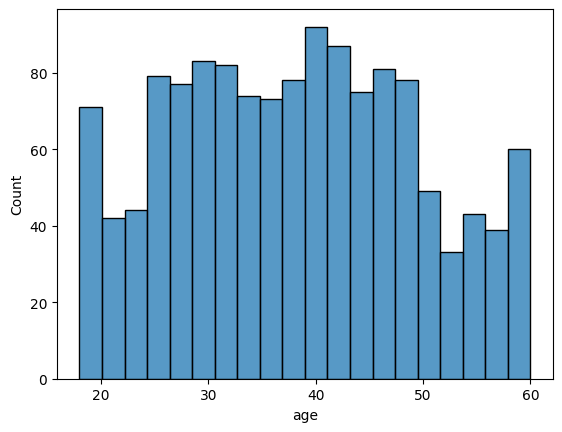

In [31]:

sns.histplot(data=df, x="age", bins=20)
plt.show()

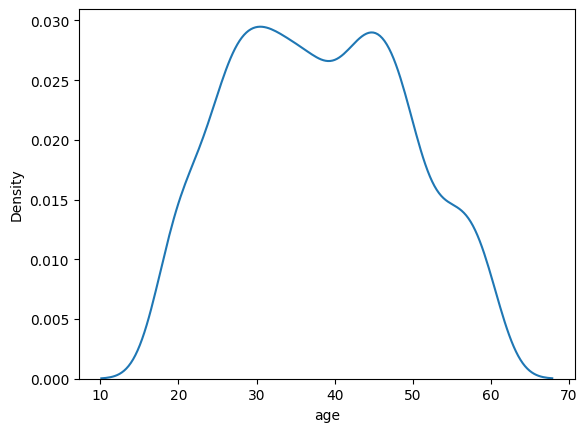

In [35]:
sns.kdeplot(data=df, x='age')
plt.show()

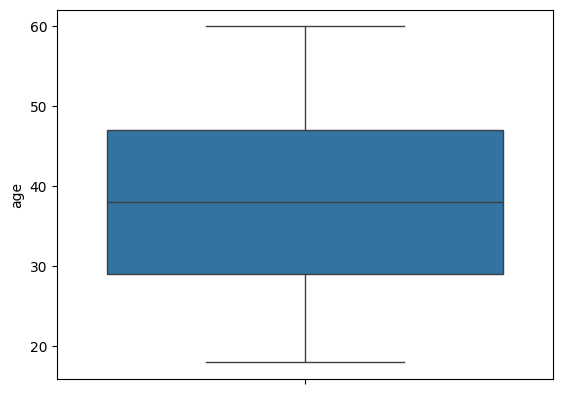

In [34]:
sns.boxplot(data=df, y='age')
plt.show()

### **bmi**

- bmi is distributed complete normally

- There are some outliers

In [37]:
df["bmi"].describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

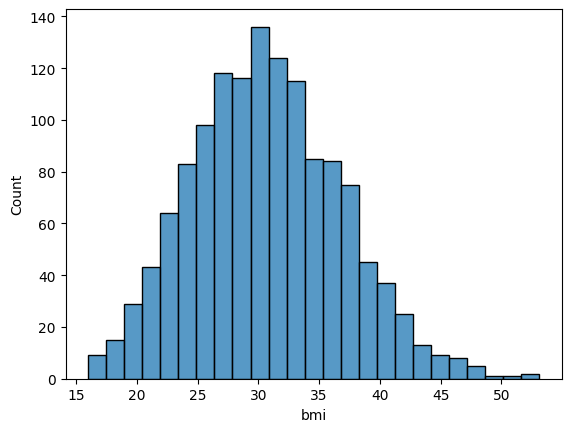

In [40]:
sns.histplot(data=df, x='bmi')
plt.show()

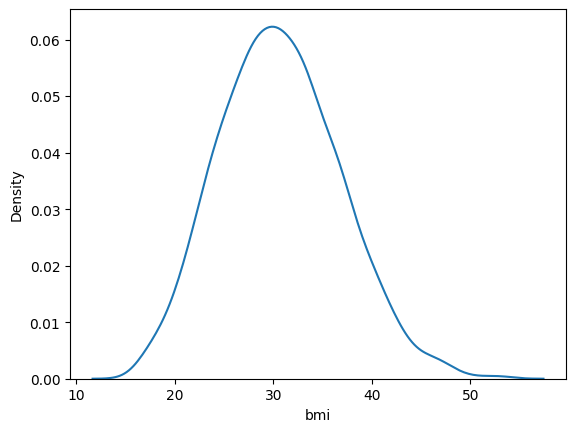

In [42]:
sns.kdeplot(data=df, x='bmi')
plt.show()

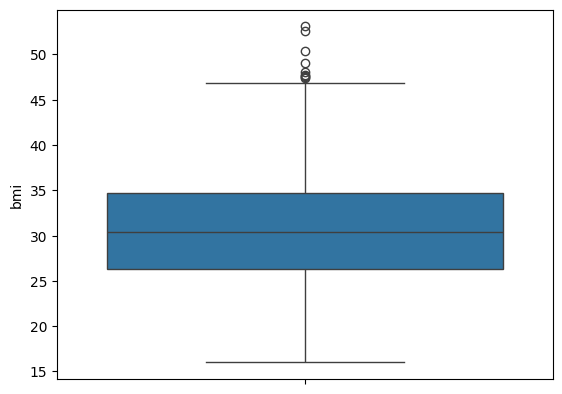

In [44]:
sns.boxplot(data=df, y='bmi')
plt.show()

In [45]:
df[df["bmi"]>48]

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,10,30,male,53.1,97,No,0,No,northwest,1163.46
141,142,46,male,50.4,89,Yes,1,No,southeast,2438.06
675,676,49,female,48.1,81,Yes,2,No,northeast,9432.93
802,803,42,male,49.1,109,Yes,0,No,southeast,11381.33
1299,1300,50,male,52.6,110,No,1,Yes,southeast,44501.40


### **bloodpressure**

- data is right skewed distributed

- there are some outliers

In [46]:
df["bloodpressure"].describe()

count    1340.000000
mean       94.157463
std        11.434712
min        80.000000
25%        86.000000
50%        92.000000
75%        99.000000
max       140.000000
Name: bloodpressure, dtype: float64

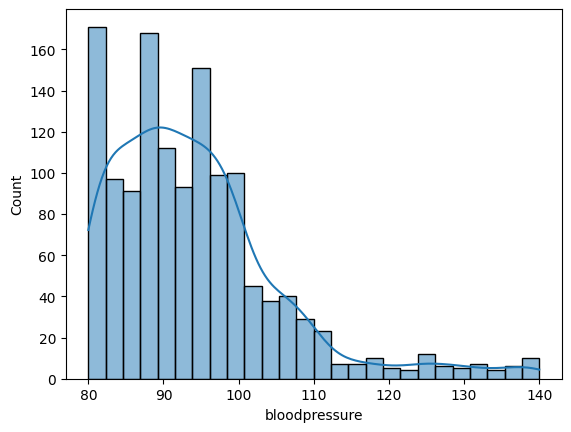

In [50]:
sns.histplot(data=df, x='bloodpressure', kde=True)
plt.show()

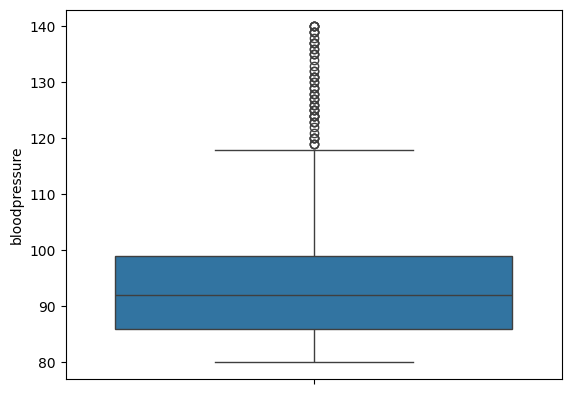

In [52]:
sns.boxplot(data=df, y='bloodpressure')
plt.show()

In [54]:
df[df["bloodpressure"]>120].head()

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1147,1148,29,female,32.7,128,Yes,2,No,northwest,26018.95
1150,1151,55,female,27.1,135,No,1,No,southwest,26140.36
1152,1153,38,female,35.9,128,No,1,No,northeast,26392.26
1153,1154,43,male,36.8,126,No,2,No,northwest,26467.10
1154,1155,31,male,23.8,126,Yes,0,Yes,southeast,26926.51


### **claim**

- data is ewed distributed

- there are a lot of outliers

In [56]:
df["claim"].describe()

count     1340.000000
mean     13252.745642
std      12109.609288
min       1121.870000
25%       4719.685000
50%       9369.615000
75%      16604.305000
max      63770.430000
Name: claim, dtype: float64

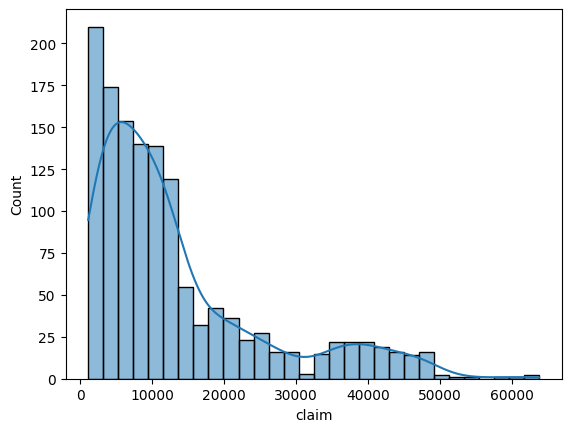

In [57]:
sns.histplot(data=df, x='claim',kde=True)
plt.show()

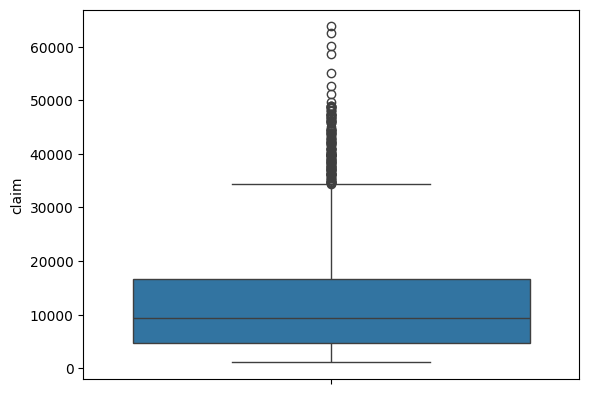

In [61]:
sns.boxplot(data=df, y='claim')
plt.show()

In [62]:
df[df['claim']>30000]

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1178,1179,27,male,37.7,95,No,3,No,northwest,30063.58
1179,1180,19,male,24.7,97,Yes,1,No,northwest,30166.62
1180,1181,39,male,29.8,110,No,3,Yes,northeast,30184.94
1181,1182,32,male,28.6,132,No,0,No,northeast,30260.00
1182,1183,36,male,25.4,84,No,2,No,northwest,30284.64
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37,male,30.4,106,No,0,Yes,southeast,62592.87


# **Categorical**

# **gender**

- data is nicely balanced


In [69]:
df["gender"].value_counts(normalize=True)*100

gender
male      50.597015
female    49.402985
Name: proportion, dtype: float64

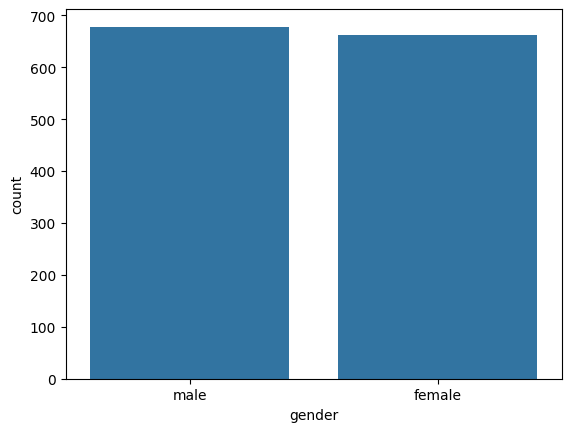

In [67]:
sns.countplot(data=df, x='gender')
plt.show()

### **diabetic**

- 52% patient has diabetic and 47% patient has no diabetic

In [75]:
df["diabetic"].value_counts(normalize=True)*100

diabetic
No     52.089552
Yes    47.910448
Name: proportion, dtype: float64

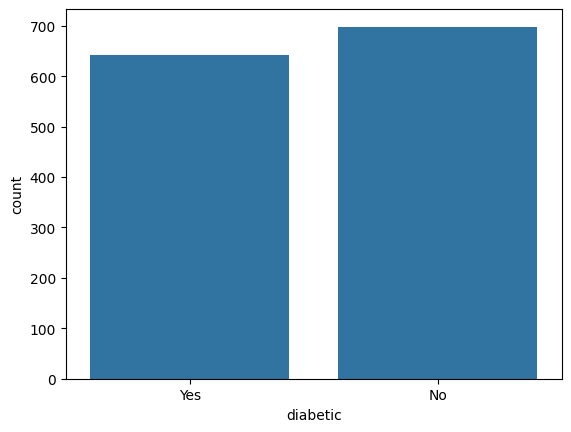

In [77]:
sns.countplot(data=df, x='diabetic')
plt.show()

### **smoker**

- There are total 79% non smoker patient and 20% smoker patient



In [79]:
df["smoker"].value_counts(normalize=True)*100

smoker
No     79.552239
Yes    20.447761
Name: proportion, dtype: float64

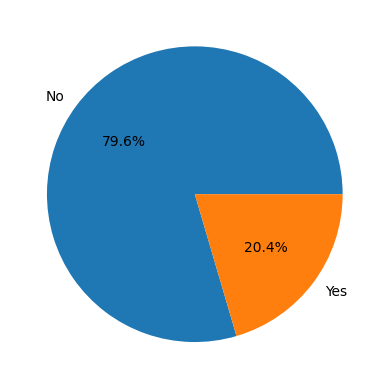

In [83]:
df['smoker'].value_counts().plot(kind='pie', autopct="%0.1f%%")
plt.show()

### **region**

- The southeast patient is slightly larger

In [85]:
df["region"].value_counts(normalize=True)*100

region
southeast    33.283582
northwest    26.044776
southwest    23.432836
northeast    17.238806
Name: proportion, dtype: float64

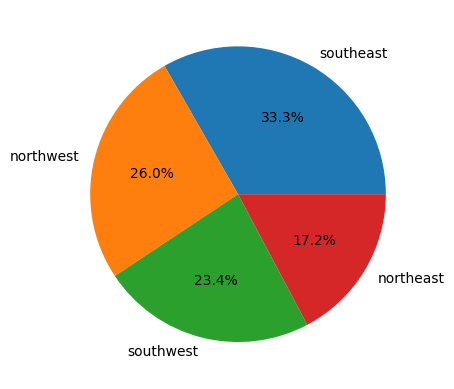

In [87]:
df["region"].value_counts().plot(kind='pie', autopct="%0.1f%%")
plt.show()

### **children**

- patient having no children are larger in data

In [91]:
df["children"].value_counts(normalize=True)*100

children
0    42.985075
1    24.179104
2    17.910448
3    11.716418
4     1.865672
5     1.343284
Name: proportion, dtype: float64

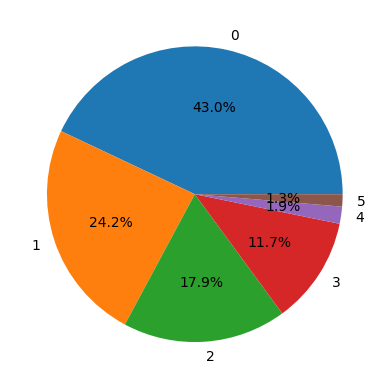

In [93]:
df["children"].value_counts().plot(kind='pie', autopct="%0.1f%%")
plt.show()

In [142]:
df

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24,male,30.1,87,No,0,No,southeast,1131.51
2,3,38,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,38,male,33.7,80,No,0,No,northwest,1136.40
4,5,38,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37,male,30.4,106,No,0,Yes,southeast,62592.87


<br>

# **Bivariate Analysis**

### **Numerical - Numerical**

### **age**

- There is no proper raltion of age eith bmi, bloodpressure and claim

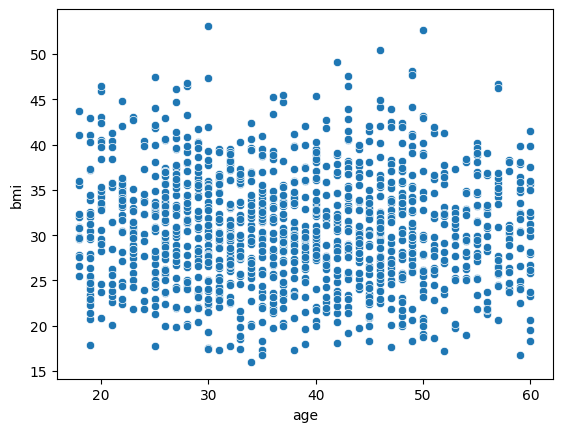

In [103]:

sns.scatterplot(data=df, x='age', y='bmi')
plt.show()

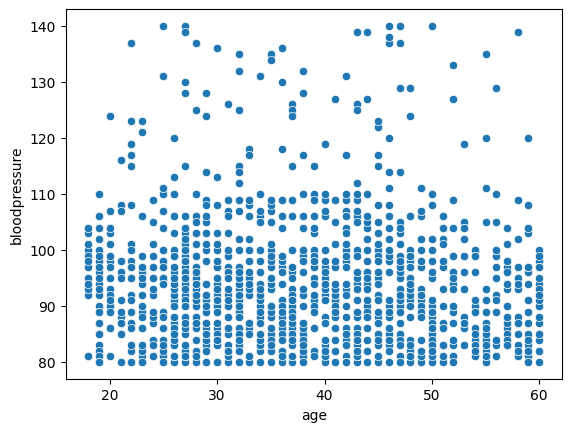

In [104]:
sns.scatterplot(data=df, x='age', y='bloodpressure')
plt.show()

<Axes: xlabel='age', ylabel='claim'>

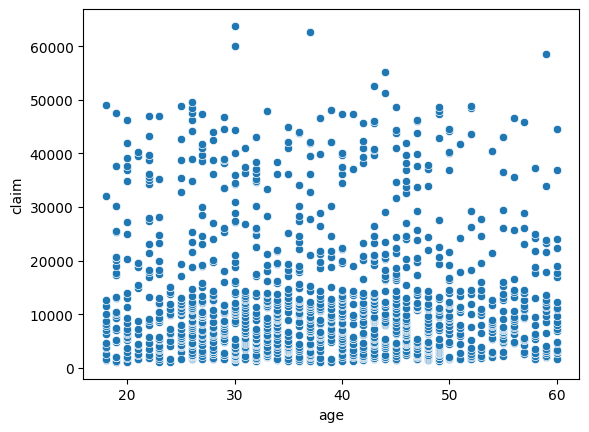

In [106]:
sns.scatterplot(data=df, x='age', y='claim')

<br>

### **bmi**

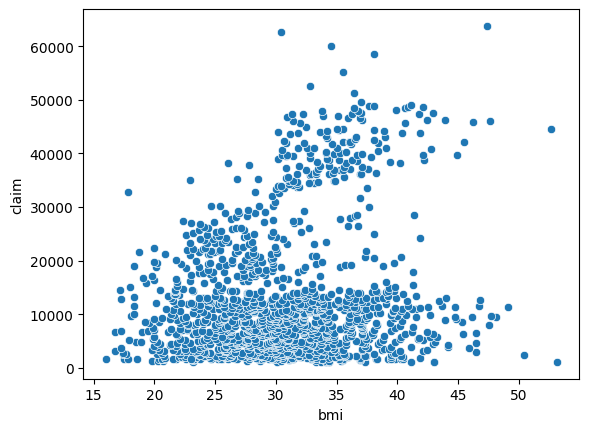

In [111]:
sns.scatterplot(data=df, x='bmi', y='claim')
plt.show()

### **bloodpressure**



<Axes: xlabel='bloodpressure', ylabel='claim'>

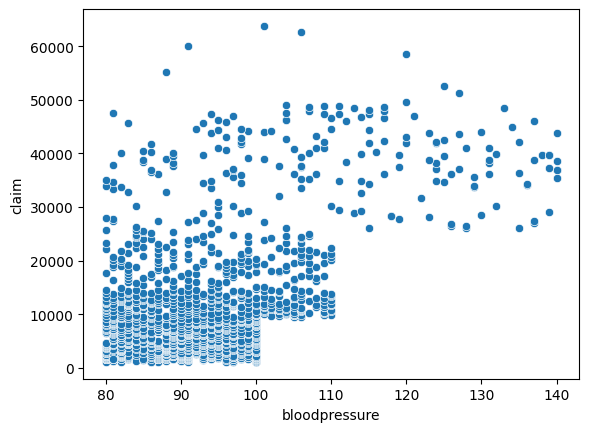

In [113]:
sns.scatterplot(data=df, x='bloodpressure', y='claim')

# **Categorical - Categorical**

### **gender**

- male smoker are greater than female smoker.

In [121]:
pd.crosstab(index=df['gender'], columns=df["smoker"])

smoker,No,Yes
gender,,
female,547,115
male,519,159


### **diabetic**



In [131]:
pd.crosstab(index=df["diabetic"], columns=df["smoker"])

smoker,No,Yes
diabetic,,
No,560,138
Yes,506,136


In [127]:
df["smoker"].value_counts(normalize=True)*100

smoker
No     79.552239
Yes    20.447761
Name: proportion, dtype: float64

# **Categorical - Numerical**

- smoker patient have high claim

In [134]:
df.columns

Index(['PatientID', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic',
       'children', 'smoker', 'region', 'claim'],
      dtype='str')

<Axes: xlabel='gender', ylabel='claim'>

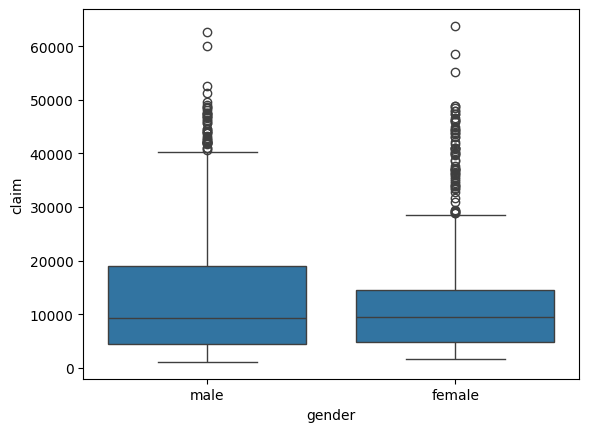

In [140]:
sns.boxplot(data=df, x='gender', y='claim')

<Axes: xlabel='smoker', ylabel='claim'>

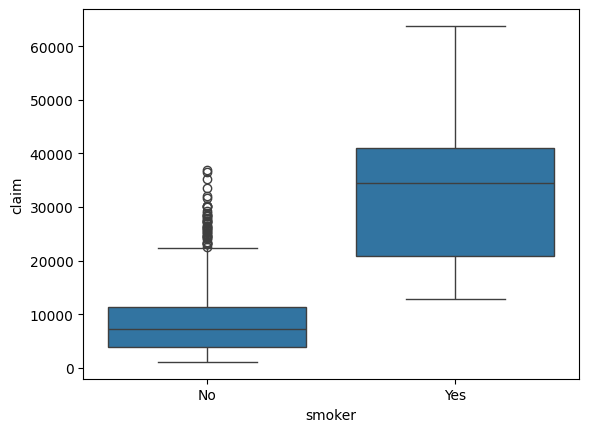

In [144]:
sns.boxplot(data=df, x='smoker', y='claim')

In [145]:
df.groupby('smoker')["claim"].mean()

smoker
No      8421.121576
Yes    32050.231971
Name: claim, dtype: float64

<Axes: xlabel='region', ylabel='claim'>

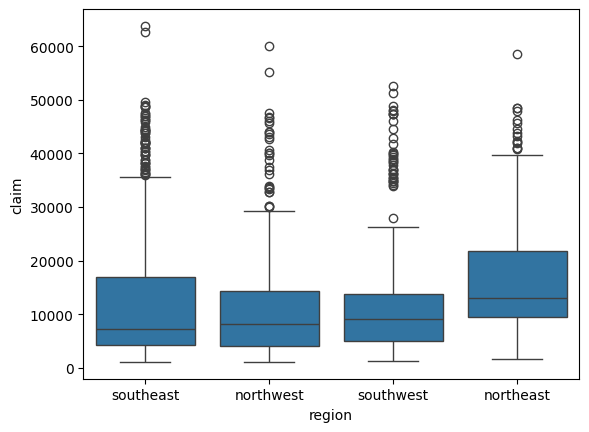

In [147]:
sns.boxplot(data=df, x='region', y='claim')

### **EDA Finall summary**

- Claim rises strongly with bloodpressure
- BMI has mild increasing trend
- Children is weakly correlated
- smoker status is important for claim
